<a href="https://colab.research.google.com/github/rida09Heythere/mental-health-cycle-tracker/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gspread oauth2client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 2.4 MB/s eta 0:00:00


In [3]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials
scope=["https://spreadsheets.google.com/feeds",
       "https://www.googleapis.com/auth/drive"]
creds=ServiceAccountCredentials.from_json_keyfile_name("cycle-tracker-r.json",scope)
client=gspread.authorize(creds)

sheet = client.open("Cycle-Tracker-data").sheet1
print("connected successfully")

connected successfully


In [ ]:
sheet=client.open("Cycle-Tracker-data").sheet1
import datetime
test_row=[
    str(datetime.datetime.now()),
    "Test User",
    "23",
    "Luteal",
    "6",
    "7",
    "Work stress",
    "N/A"

]
sheet.append_row(test_row)
print("Row added successsfully")

Row added successsfully


In [ ]:
print(sheet.get_all_records)

<bound method Worksheet.get_all_records of <Worksheet 'Sheet1' id:0>>


In [ ]:
!pip install pyTelegramBotAPI

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 13.9 MB/s eta 0:00:00


In [ ]:
import telebot
TOKEN ="7961938129:AAGhSH3156G-TTZcHG4UbxkdKjPLastbPLc"
bot=telebot.TeleBot(TOKEN)
print("Bot connected")

Bot connected


In [ ]:
updates=bot.get_updates()
print(updates)

[<telebot.types.Update object at 0x7ad57c29e030>, <telebot.types.Update object at 0x7ad57c29f5f0>]


In [ ]:
updates=bot.get_updates()
chat_id=updates[0].message.chat.id
print(chat_id)

5017723367


In [ ]:
chat_id= 5017723367
bot.send_message(chat_id,"Hello! Welcome to Cycle Tracker Bot <3 Your weekly check-in is ready!")
print("Message sent!")

Message sent!


In [ ]:
questions=[
    "How many hours did you sleep this week on average? (eg.=6)",
    "How would you rate your anxiety this week ? (1-10)",
    "Did you exercise this week? (Yes/No)",
    "What were your main stress triggers this week?",
    "What Phase is your cycle in? (Menstrual/Follicular/Ovulation/Luteal)",
    "Did last week's suggestions help? (Yes/No/First time)"
]
for question in questions:
  bot.send_message(chat_id,question)
  print("Question sent!")

Question sent!
Question sent!
Question sent!
Question sent!
Question sent!
Question sent!


In [ ]:
updates=bot.get_updates()
last_update_id=updates[-1].update_id
print(last_update_id)

46045565


In [ ]:
bot.get_updates(offset=46045565)
updates=bot.get_updates(offset=-1)
last_message=updates[-1].message.text
print(last_message)


,6


In [ ]:
import time

def get_reply(last_update_id):
  while True:
    updates=bot.get_updates(offset=last_update_id + 1)
    if updates:
      answer=updates[-1].message.text
      last_update_id=updates[-1].update_id
      return answer , last_update_id
    time.sleep(3)


In [ ]:
import time

def get_reply(last_update_id):
  while True:
    updates=bot.get_updates(offset=last_update_id + 1)
    if updates:
      answer=updates[-1].message.text
      last_update_id=updates[-1].update_id
      return answer , last_update_id
    time.sleep(3)


In [ ]:
from re import A
updates=bot.get_updates(offset=-1)
last_update_id=updates[-1].update_id

#1
bot.send_message(chat_id,"What is your dear Name?")
answer1,last_update_id=get_reply(last_update_id)

#2
bot.send_message(chat_id,"How old are you?")
answer2, last_update_id=get_reply(last_update_id)

#3
bot.send_message(chat_id,"What Phase is your cycle in? (Menstrual/Follicular/Ovulation/Luteal)")
answer3, last_update_id=get_reply(last_update_id)

#4
bot.send_message(chat_id,"How many hours did you sleep this week on average? eg 6")
answer4, last_update_id=get_reply(last_update_id)

#5
bot.send_message(chat_id,"How was Your anxiety this week from 1-10")
answer5, last_update_id=get_reply(last_update_id)

#6
bot.send_message(chat_id,"Did you exercise this week Yes/No")
answer6, last_update_id=get_reply(last_update_id)

#7
bot.send_message(chat_id,"What were your main stress triggers this week?")
answer7, last_update_id=get_reply(last_update_id)

#8
bot.send_message(chat_id,"Did last week's suggestions help? (Yes/No/First time)")
answer8, last_update_id=get_reply(last_update_id)

print("All done")

#

All done


In [ ]:
import datetime
sheet.append_row([
    str(datetime.datetime.now()),
    answer1,
    answer2,
    answer3,
    answer4,
    answer5,
    answer6,
    answer7,
    answer8
])
print("saved to sheets")

saved to sheets


In [26]:
import pandas as pd
#get data from sheets
data=sheet.get_all_records()
#df
df=pd.DataFrame(data)
print(df.head())
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())

                   Time Stamp     Name Age Cycle Phase Sleep Hours  \
0                                                                    
1  2026-04-30 18:49:24.115471   Riddhi  23  Follicular           6   
2  2026-05-02 16:27:18.347920    Amaya  18      Luteal           8   
3  2026-05-02 16:56:09.061466  Amayana  32   Menstrual           4   
4  2026-05-02 17:36:17.567211  Smaayra  20   Ovulation           9   

  Anxiety Score Exercise Stress Triggers Suggestions Helped  
0                                                            
1             7      yes     work stress                     
2             8      yes       Boyfriend                     
3             9       no          family                     
4             5       no          future                     
(9, 9)
Index(['Time Stamp', 'Name', 'Age', 'Cycle Phase', 'Sleep Hours',
       'Anxiety Score', 'Exercise', 'Stress Triggers', 'Suggestions Helped'],
      dtype='object')
Time Stamp            object
Name 

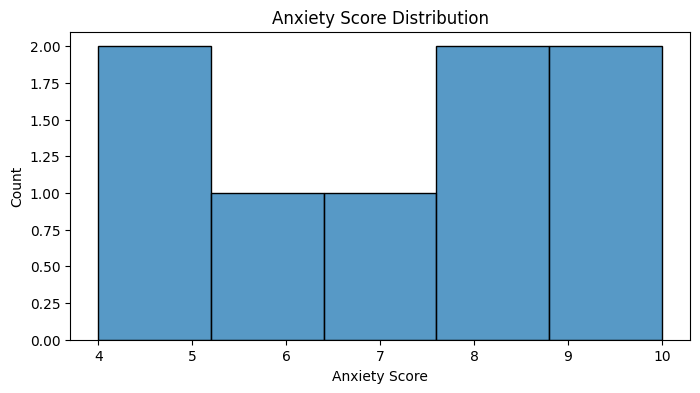

In [27]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
df['Anxiety Score']= pd.to_numeric(df['Anxiety Score'],errors='coerce')
df=df.dropna(subset=['Anxiety Score'])
df['Anxiety Score']=df['Anxiety Score'].astype(int)
sns.histplot(df['Anxiety Score'],bins=5)
plt.title('Anxiety Score Distribution')
plt.xlabel('Anxiety Score')
plt.ylabel('Count')
plt.show()

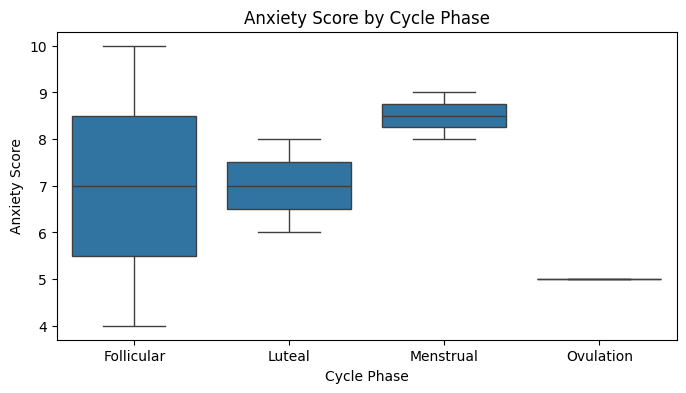

In [28]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Cycle Phase',y='Anxiety Score' ,data=df)
plt.title('Anxiety Score by Cycle Phase')
plt.xlabel('Cycle Phase')
plt.ylabel('Anxiety Score')
plt.show()



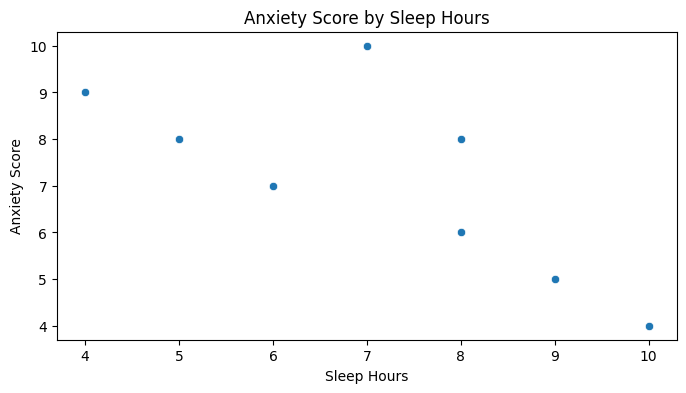

               Sleep Hours  Anxiety Score
Sleep Hours       1.000000      -0.731602
Anxiety Score    -0.731602       1.000000


In [29]:
plt.figure(figsize=(8,4))
sns.scatterplot(x='Sleep Hours',y='Anxiety Score',data=df)
plt.title('Anxiety Score by Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Anxiety Score')
plt.show()
print(df[['Sleep Hours', 'Anxiety Score']].corr())


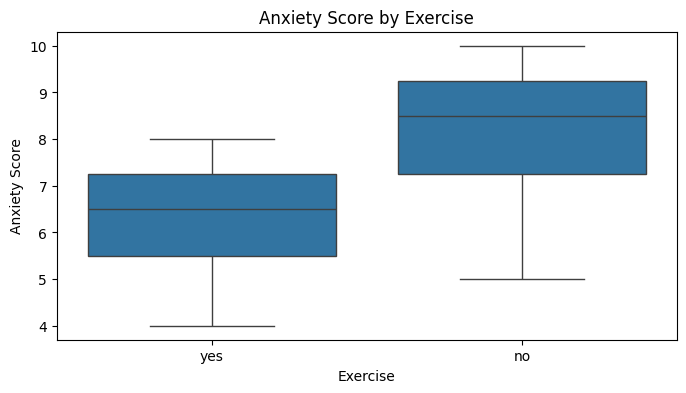

In [30]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Exercise',y='Anxiety Score',data=df)
plt.title('Anxiety Score by Exercise')
plt.xlabel('Exercise')
plt.ylabel('Anxiety Score')
plt.show()